**Scratch Gradient Descent**
- **Task:** Write a Python loop that minimizes the function f(x, y) = x^2 + 4y^2 using standard Gradient Descent. Track the (x, y)  coordinates at each step and plot the optimization path over a contour plot of the function using Matplotlib.
- **Why:** Connects the abstract concept of optimization to a concrete 2D landscape.

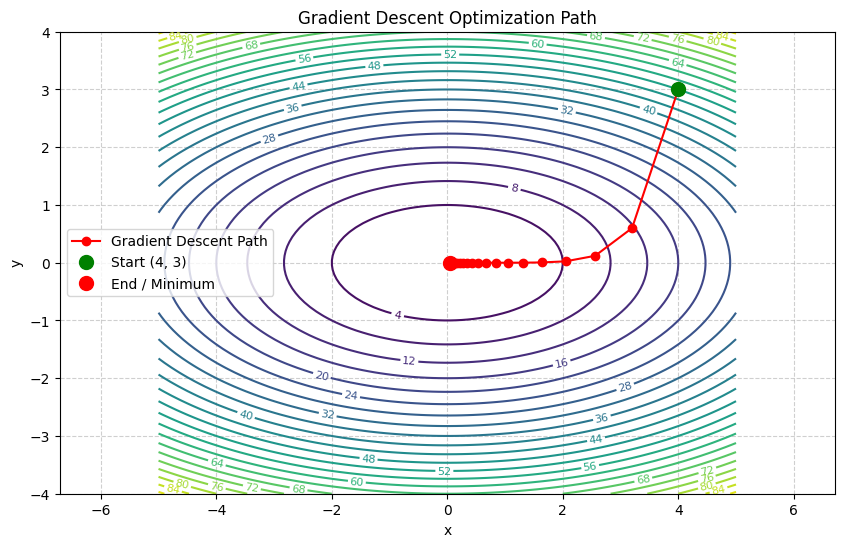

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Define the objective function and its gradient
def f(x, y):
    return x**2 + 4 * y**2

def grad_f(x, y):
    # Partial derivatives: df/dx = 2x, df/dy = 8y
    return np.array([2 * x, 8 * y])

# 2. Gradient Descent Hyperparameters
learning_rate = 0.1
iterations = 20

# Initial starting point
current_pos = np.array([4.0, 3.0])

# Array to track the history of coordinates
history = [current_pos.copy()]

# 3. Optimization Loop
for _ in range(iterations):
    # Calculate the gradient at the current position
    gradient = grad_f(current_pos[0], current_pos[1])
    
    # Update position: move opposite to the gradient
    current_pos = current_pos - learning_rate * gradient
    
    # Store the new position
    history.append(current_pos.copy())

history = np.array(history)

# 4. Visualization
# Create a grid for the contour plot
x_vals = np.linspace(-5, 5, 100)
y_vals = np.linspace(-4, 4, 100)
X, Y = np.meshgrid(x_vals, y_vals)
Z = f(X, Y)

plt.figure(figsize=(10, 6))

# Plot the function landscape contours
contours = plt.contour(X, Y, Z, levels=25, cmap='viridis')
plt.clabel(contours, inline=True, fontsize=8)

# Plot the optimization path
plt.plot(history[:, 0], history[:, 1], '-o', color='red', label='Gradient Descent Path')
plt.plot(history[0, 0], history[0, 1], 'go', markersize=10, label='Start (4, 3)')
plt.plot(history[-1, 0], history[-1, 1], 'ro', markersize=10, label='End / Minimum')

# Layout settings
plt.title('Gradient Descent Optimization Path')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.axis('equal')

plt.show()

**Momentum vs. Adam Race**
- **Task:** Implement Momentum SGD and Adam optimizers from scratch in NumPy. Create a difficult, non-convex mathematical function (e.g., the Rosenbrock function or "Valley"). Plot the trajectory of standard SGD, Momentum, and Adam starting from the same point.
- **Why:** Deeply cements why Adam uses running averages of gradients (first moment) and squared gradients (second moment) to escape flat regions and navigate ravines.

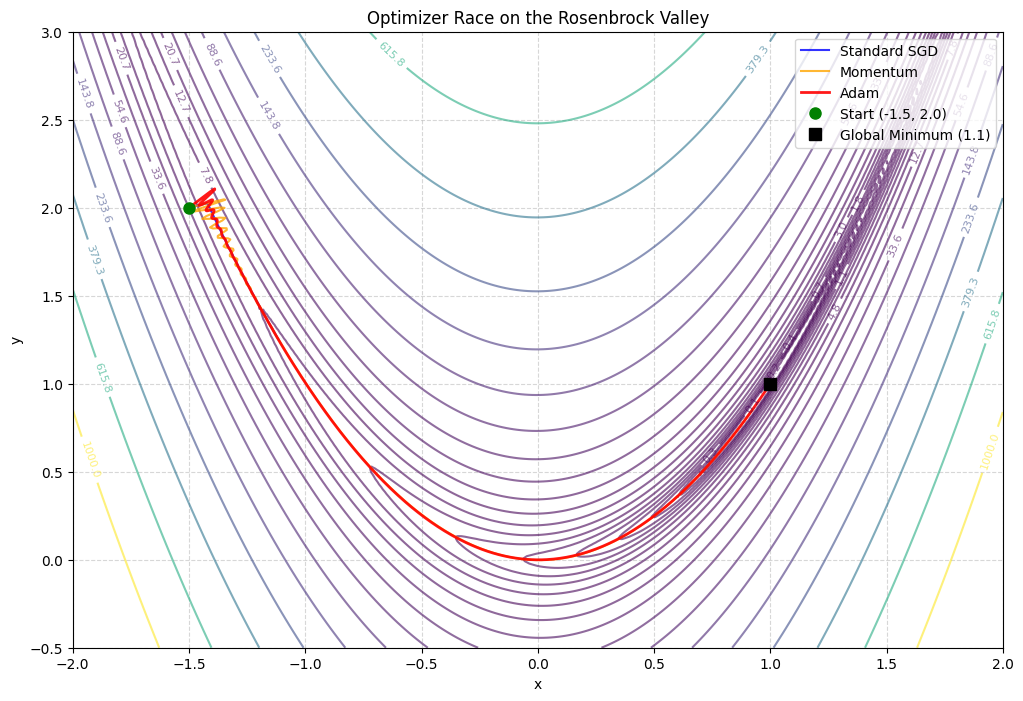

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Define the Rosenbrock "Banana" Function and its Gradient
# f(x, y) = (a - x)^2 + b * (y - x^2)^2, where a=1, b=100
def rosenbrock(x, y):
    return (1.0 - x)**2 + 100.0 * (y - x**2)**2

def grad_rosenbrock(x, y):
    df_dx = -2.0 * (1.0 - x) - 400.0 * x * (y - x**2)
    df_dy = 200.0 * (y - x**2)
    return np.array([df_dx, df_dy])

# 2. Optimization Parameters
start_point = np.array([-1.5, 2.0])  # Same starting position for all
iterations = 1000

# 3. Optimizer Implementations
def optimize_sgd(start, lr=0.0005, steps=iterations):
    w = start.copy()
    history = [w.copy()]
    for _ in range(steps):
        grad = grad_rosenbrock(w[0], w[1])
        w -= lr * grad
        history.append(w.copy())
    return np.array(history)

def optimize_momentum(start, lr=0.0005, beta=0.9, steps=iterations):
    w = start.copy()
    v = np.zeros_like(w)
    history = [w.copy()]
    for _ in range(steps):
        grad = grad_rosenbrock(w[0], w[1])
        v = beta * v + lr * grad
        w -= v
        history.append(w.copy())
    return np.array(history)

def optimize_adam(start, lr=0.05, beta1=0.9, beta2=0.999, eps=1e-8, steps=iterations):
    w = start.copy()
    m = np.zeros_like(w)
    v = np.zeros_like(w)
    history = [w.copy()]
    for t in range(1, steps + 1):
        grad = grad_rosenbrock(w[0], w[1])
        
        # Update biased first and second moment estimate
        m = beta1 * m + (1.0 - beta1) * grad
        v = beta2 * v + (1.0 - beta2) * (grad ** 2)
        
        # Compute bias-corrected estimates
        m_hat = m / (1.0 - beta1 ** t)
        v_hat = v / (1.0 - beta2 ** t)
        
        # Update weights
        w -= lr * m_hat / (np.sqrt(v_hat) + eps)
        history.append(w.copy())
    return np.array(history)

# Run the optimizers
history_sgd = optimize_sgd(start_point)
history_momentum = optimize_momentum(start_point)
history_adam = optimize_adam(start_point)

# 4. Visualization
x_vals = np.linspace(-2.0, 2.0, 250)
y_vals = np.linspace(-0.5, 3.0, 250)
X, Y = np.meshgrid(x_vals, y_vals)
Z = rosenbrock(X, Y)

plt.figure(figsize=(12, 8))

# Use log scale for contours to clearly see the narrow valley
contours = plt.contour(X, Y, Z, levels=np.logspace(-1, 3, 20), cmap='viridis', alpha=0.6)
plt.clabel(contours, inline=True, fontsize=8)

# Plot trajectories
plt.plot(history_sgd[:, 0], history_sgd[:, 1], label='Standard SGD', color='blue', alpha=0.8, linewidth=1.5)
plt.plot(history_momentum[:, 0], history_momentum[:, 1], label='Momentum', color='orange', alpha=0.8, linewidth=1.5)
plt.plot(history_adam[:, 0], history_adam[:, 1], label='Adam', color='red', alpha=0.9, linewidth=2)

# Mark key points
plt.plot(start_point[0], start_point[1], 'go', markersize=8, label='Start (-1.5, 2.0)')
plt.plot(1.0, 1.0, 'ks', markersize=8, label='Global Minimum (1.1)')

plt.title('Optimizer Race on the Rosenbrock Valley')
plt.xlabel('x')
plt.ylabel('y')
plt.legend(loc='upper right')
plt.grid(True, linestyle='--', alpha=0.5)
plt.xlim(-2.0, 2.0)
plt.ylim(-0.5, 3.0)

plt.show()